<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 60%,#1c2128 100%);padding:50px 40px;border-radius:16px;border-left:6px solid #2980b9;margin-bottom:20px;">
  <h1 style="color:#ffffff;font-size:2.8em;margin:0;font-weight:900;letter-spacing:-1px;">CRIMINALÍSTICA CATALUÑA</h1>
  <h2 style="color:#3498db;font-size:1.4em;margin:10px 0 0 0;font-weight:400;">Análisis Estadístico · Variables OSM · Preparación para ML</h2>
  <hr style="border:none;border-top:1px solid rgba(255,255,255,0.1);margin:20px 0;">
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:15px;">
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#e74c3c;font-size:1.8em;font-weight:900;">982.882</div>
      <div style="color:#8b949e;font-size:0.85em;">registros en BD</div></div>
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#3498db;font-size:1.8em;font-weight:900;">6 secciones</div>
      <div style="color:#8b949e;font-size:0.85em;">análisis estadístico</div></div>
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#2ecc71;font-size:1.8em;font-weight:900;">OSM</div>
      <div style="color:#8b949e;font-size:0.85em;">variables de afluencia</div></div>
    <div style="background:rgba(255,255,255,0.05);padding:15px;border-radius:8px;text-align:center;">
      <div style="color:#f39c12;font-size:1.8em;font-weight:900;">→ nb10</div>
      <div style="color:#8b949e;font-size:0.85em;">features_ml.csv</div></div>
  </div>
  <p style="color:#8b949e;margin:20px 0 0 0;font-size:0.85em;">Proyecto Final &middot; IT Academy Barcelona &middot; 2026 &nbsp;|&nbsp; Produce: <strong style="color:#3498db;">osm_afluencia_barri.csv</strong> &nbsp;&middot;&nbsp; <strong style="color:#f39c12;">features_ml.csv</strong></p>
</div>

## Librerías instaladas en este notebook

| Librería | Para qué se usa |
|---|---|
| **osmnx** | Descarga puntos de interés (POIs) de OpenStreetMap por tipo de actividad (ocio, turismo, comercio, transporte). Construye las **variables de afluencia** por barrio que controlan el sesgo de exposición detectado en el EDA |
| **geopandas** | Realiza el *spatial join*: asigna cada POI descargado al barrio en que cae geográficamente, usando los polígonos WKT de `geo_territorio` |
| **statsmodels** | Tests estadísticos formales: **OLS** (tabla de coeficientes con p-values e IC), **ADF** (estacionariedad de series temporales), **ACF/PACF** (autocorrelaciones para identificar lags óptimos para ML) |
| **scikit-learn** | **K-Means** (clustering de barrios por perfil), **PCA** (reducción a 2D para visualizar clusters), **StandardScaler** (normalización: K-Means es sensible a la escala de las variables) |
| **pymannkendall** | Test de **Mann-Kendall**: detecta tendencias monótonas en series temporales sin asumir normalidad. El test estándar en análisis de series de crimen |

In [1]:
import subprocess, sys

libs = {
    'osmnx':         'POIs OpenStreetMap → variables de afluencia por barrio',
    'geopandas':     'spatial join barrios x POIs (asignacion geografica)',
    'statsmodels':   'OLS, ADF (estacionariedad), ACF/PACF formales',
    'scikit-learn':  'K-Means, PCA, StandardScaler',
    'pymannkendall': 'test Mann-Kendall para tendencias no parametricas',
}

for pkg, desc in libs.items():
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    print(f'[OK] {pkg:<20s} {desc}')

print('\nTodos los paquetes listos.')

[OK] osmnx                POIs OpenStreetMap → variables de afluencia por barrio
[OK] geopandas            spatial join barrios x POIs (asignacion geografica)
[OK] statsmodels          OLS, ADF (estacionariedad), ACF/PACF formales
[OK] scikit-learn         K-Means, PCA, StandardScaler
[OK] pymannkendall        test Mann-Kendall para tendencias no parametricas

Todos los paquetes listos.


In [2]:
import os, warnings, getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats as scipy_stats
from sqlalchemy import create_engine

# Librerias instaladas arriba
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf as acf_vals
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pymannkendall as mk
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import geopandas as gpd
import osmnx as ox
from shapely import wkt as shapely_wkt
from shapely.geometry import mapping

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False
})
COL_CRIME = '#c0392b'
COL_GUB   = '#2980b9'
COL_OSM   = '#16a085'
COL_SOCIO = '#8e44ad'
MESES_ES  = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
print('[OK] Imports listos')

[OK] Imports listos


In [3]:
user = os.getenv('MYSQL_USER', 'root')
pwd  = os.getenv('MYSQL_PASSWORD') or getpass.getpass('MySQL password: ')
host = os.getenv('MYSQL_HOST', 'localhost')
port = int(os.getenv('MYSQL_PORT', '3306'))
db   = os.getenv('MYSQL_DB', 'criminalistica_cat')

engine = create_engine(f'mysql+pymysql://{user}:{pwd}@{host}:{port}/{db}?charset=utf8mb4')

print('Cargando tablas desde MySQL...')
dim_tiempo        = pd.read_sql('SELECT * FROM dim_tiempo',                 engine)
dim_territorio    = pd.read_sql('SELECT * FROM dim_territorio',              engine)
dim_tipo_delito   = pd.read_sql('SELECT * FROM dim_tipo_delito',             engine)
fact_mossos       = pd.read_sql('SELECT * FROM fact_delitos_mossos',         engine)
fact_gub          = pd.read_sql('SELECT * FROM fact_incidentes_gub',         engine)
ctx_socio         = pd.read_sql('SELECT * FROM contexto_socioeconomico',     engine)
ctx_poblacion     = pd.read_sql('SELECT * FROM contexto_poblacion',          engine)
ctx_renta_barri   = pd.read_sql('SELECT * FROM contexto_renta_barri',        engine)
geo               = pd.read_sql('SELECT * FROM geo_territorio',              engine)
print('[OK] Carga completa')

Cargando tablas desde MySQL...
[OK] Carga completa


In [4]:
_tablas = {
    'dim_tiempo': dim_tiempo, 'dim_territorio': dim_territorio,
    'dim_tipo_delito': dim_tipo_delito,
    'fact_delitos_mossos': fact_mossos, 'fact_incidentes_gub': fact_gub,
    'ctx_socioeconomico': ctx_socio, 'ctx_poblacion': ctx_poblacion,
    'ctx_renta_barri': ctx_renta_barri, 'geo_territorio': geo,
}
display(pd.DataFrame({
    'filas': {k: f'{len(v):,}' for k, v in _tablas.items()},
    'cols':  {k: len(v.columns) for k, v in _tablas.items()},
}))
print(f'TOTAL: {sum(len(v) for v in _tablas.values()):,} filas en {len(_tablas)} tablas')

,filas,cols
dim_tiempo,208,5
dim_territorio,141,12
dim_tipo_delito,356,7
fact_delitos_mossos,"321,188",7
fact_incidentes_gub,"543,709",5
ctx_socioeconomico,"1,247",10
ctx_poblacion,"79,587",7
ctx_renta_barri,"1,241",10
geo_territorio,129,5


TOTAL: 947,806 filas en 9 tablas


---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">0 &middot; Variables de Afluencia (OpenStreetMap)</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">El EDA detectó que renta y educación correlacionan con incidentes en absoluto pero el efecto desaparece per cápita (<em>sesgo de exposición</em>): los barrios con más tránsito acumulan crímenes por afluencia, no por pobreza. Aquí construimos variables que miden directamente ese tránsito.</p>
</div>

<div style="background:#eaf4fb;border-left:4px solid #2980b9;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Qué descargamos de OpenStreetMap y por qué cada categoría:</strong><br><br>
<ul>
<li><strong>n_ocio</strong> (bares, pubs, discotecas, restaurantes): proxy del <em>nightlife</em>. Zonas de ocio concentran robos, agresiones y delitos sexuales, especialmente de noche y fin de semana.</li>
<li><strong>n_turismo</strong> (hoteles, museos, atracciones): proxy de turistas. Los turistas son objetivo frecuente de carteristas y hurtos; concentran la demanda de delitos oportunistas.</li>
<li><strong>n_comercio</strong> (supermercados, tiendas de ropa, electrónica): proxy de afluencia diurna y hurtos en comercio.</li>
<li><strong>n_transport</strong> (paradas metro, bus, tren): proxy del flujo de personas en tránsito. Nodos de transporte concentran hurtos de bolso y carteras.</li>
</ul>
<strong>Resultado esperado:</strong> los barrios turísticos (Gòtic, Eixample, Raval) tendrán valores altos en las 4 categorías, lo que explica sus altos incidentes absolutos <em>sin</em> que eso implique mayor riesgo per cápita para sus residentes.
</div>

In [5]:
OSM_PATH = '../data/clean/osm_afluencia_barri.csv'

if not os.path.exists(OSM_PATH):
    print('Descargando datos de OpenStreetMap (primera vez, ~60-120s)...')

    # Cargar geometrias de barrios y convertir WKT a geometrias shapely
    geo_barri = geo[geo['nivel_territorial'] == 'barri'].copy()
    geo_barri['geometry'] = geo_barri['geometria_wgs84'].apply(
        lambda x: shapely_wkt.loads(x) if pd.notna(x) else None
    )
    geo_barri = geo_barri.dropna(subset=['geometry'])
    gdf = gpd.GeoDataFrame(geo_barri[['id_territorio', 'geometry']], crs='EPSG:4326')

    def _contar_pois(tags, nombre):
        try:
            pois = ox.features_from_place('Barcelona, Spain', tags=tags)
            # Reducir a puntos: los poligonos usan su centroide
            pois = pois.copy()
            pois['geometry'] = pois.geometry.apply(
                lambda g: g.centroid if g.geom_type != 'Point' else g
            )
            pois_gdf = gpd.GeoDataFrame(pois[['geometry']], crs='EPSG:4326')
            joined   = gpd.sjoin(pois_gdf, gdf, how='left', predicate='within')
            serie    = joined.groupby('id_territorio').size().rename(nombre)
            print(f'  [OK] {nombre}: {len(pois):,} POIs descargados')
            return serie
        except Exception as e:
            print(f'  [WARN] {nombre} fallo: {e}')
            return pd.Series(dtype=int, name=nombre)

    tags_map = {
        'n_ocio':      {'amenity': ['bar', 'pub', 'nightclub', 'restaurant', 'fast_food', 'cafe']},
        'n_turismo':   {'tourism': ['hotel', 'hostel', 'attraction', 'museum', 'gallery']},
        'n_comercio':  {'shop': ['supermarket', 'convenience', 'clothes', 'shoes', 'electronics', 'bakery']},
        'n_transport': {'public_transport': ['stop_position', 'station'],
                        'railway': ['station', 'halt'], 'highway': ['bus_stop']},
    }

    series = {nom: _contar_pois(tags, nom) for nom, tags in tags_map.items()}

    df_osm = gdf[['id_territorio']].copy()
    for nom, serie in series.items():
        df_osm = df_osm.merge(serie.reset_index(), on='id_territorio', how='left')
    for col in tags_map.keys():
        df_osm[col] = df_osm[col].fillna(0).astype(int)

    # Agregar nombre de barrio para legibilidad
    df_osm = df_osm.merge(
        dim_territorio[['id_territorio', 'nom_barri', 'nom_districte']]
        .dropna(subset=['nom_barri']),
        on='id_territorio', how='left'
    )
    df_osm['afluencia_total'] = df_osm[list(tags_map.keys())].sum(axis=1)

    df_osm.to_csv(OSM_PATH, index=False)
    print(f'[OK] Guardado en {OSM_PATH} ({len(df_osm)} barrios)')
else:
    print(f'[OK] Ya existe -> saltando descarga OSM')
    print(f'     ({OSM_PATH})')

[OK] Ya existe -> saltando descarga OSM
     (../data/clean/osm_afluencia_barri.csv)


In [6]:
df_osm = pd.read_csv(OSM_PATH)

# Asegurar columna afluencia_total (por si el CSV fue generado antes de anadirla)
osm_cols = ['n_ocio', 'n_turismo', 'n_comercio', 'n_transport']
if 'afluencia_total' not in df_osm.columns:
    df_osm['afluencia_total'] = df_osm[osm_cols].sum(axis=1)

print(f'OSM cargado: {len(df_osm)} barrios')
print(f'Estadisticas por categoria:')
display(df_osm[osm_cols + ['afluencia_total']].describe().round(1))
print()
print('Top 10 barrios por afluencia total:')
display(
    df_osm.nlargest(10, 'afluencia_total')[
        ['nom_barri', 'nom_districte', 'n_ocio', 'n_turismo', 'n_comercio', 'n_transport', 'afluencia_total']
    ].reset_index(drop=True)
)

OSM cargado: 73 barrios
Estadisticas por categoria:


,n_ocio,n_turismo,n_comercio,n_transport,afluencia_total
count,73.0,73.0,73.0,73.0,73.0
mean,101.1,12.0,47.8,77.4,238.3
std,146.7,26.9,69.2,55.4,261.8
min,0.0,0.0,0.0,6.0,6.0
25%,17.0,1.0,9.0,40.0,69.0
50%,40.0,3.0,25.0,60.0,150.0
75%,110.0,13.0,50.0,96.0,258.0
max,748.0,164.0,393.0,266.0,1568.0



Top 10 barrios por afluencia total:


,nom_barri,nom_districte,n_ocio,n_turismo,n_comercio,n_transport,afluencia_total
0,la Dreta de l'Eixample,Eixample,748,164,393,263,1568
1,la Vila de Gràcia,Gràcia,518,23,314,84,939
2,l'Antiga Esquerra de l'Eixample,Eixample,527,51,148,118,844
3,el Barri Gòtic,Ciutat Vella,396,125,200,46,767
4,el Raval,Ciutat Vella,424,91,139,81,735
5,la Sagrada Família,Eixample,372,13,150,63,598
6,el Poble Sec,Sants-Montjuïc,231,46,54,266,597
7,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,350,50,103,72,575
8,Sant Antoni,Eixample,306,21,113,94,534
9,les Corts,Les Corts,220,15,155,125,515


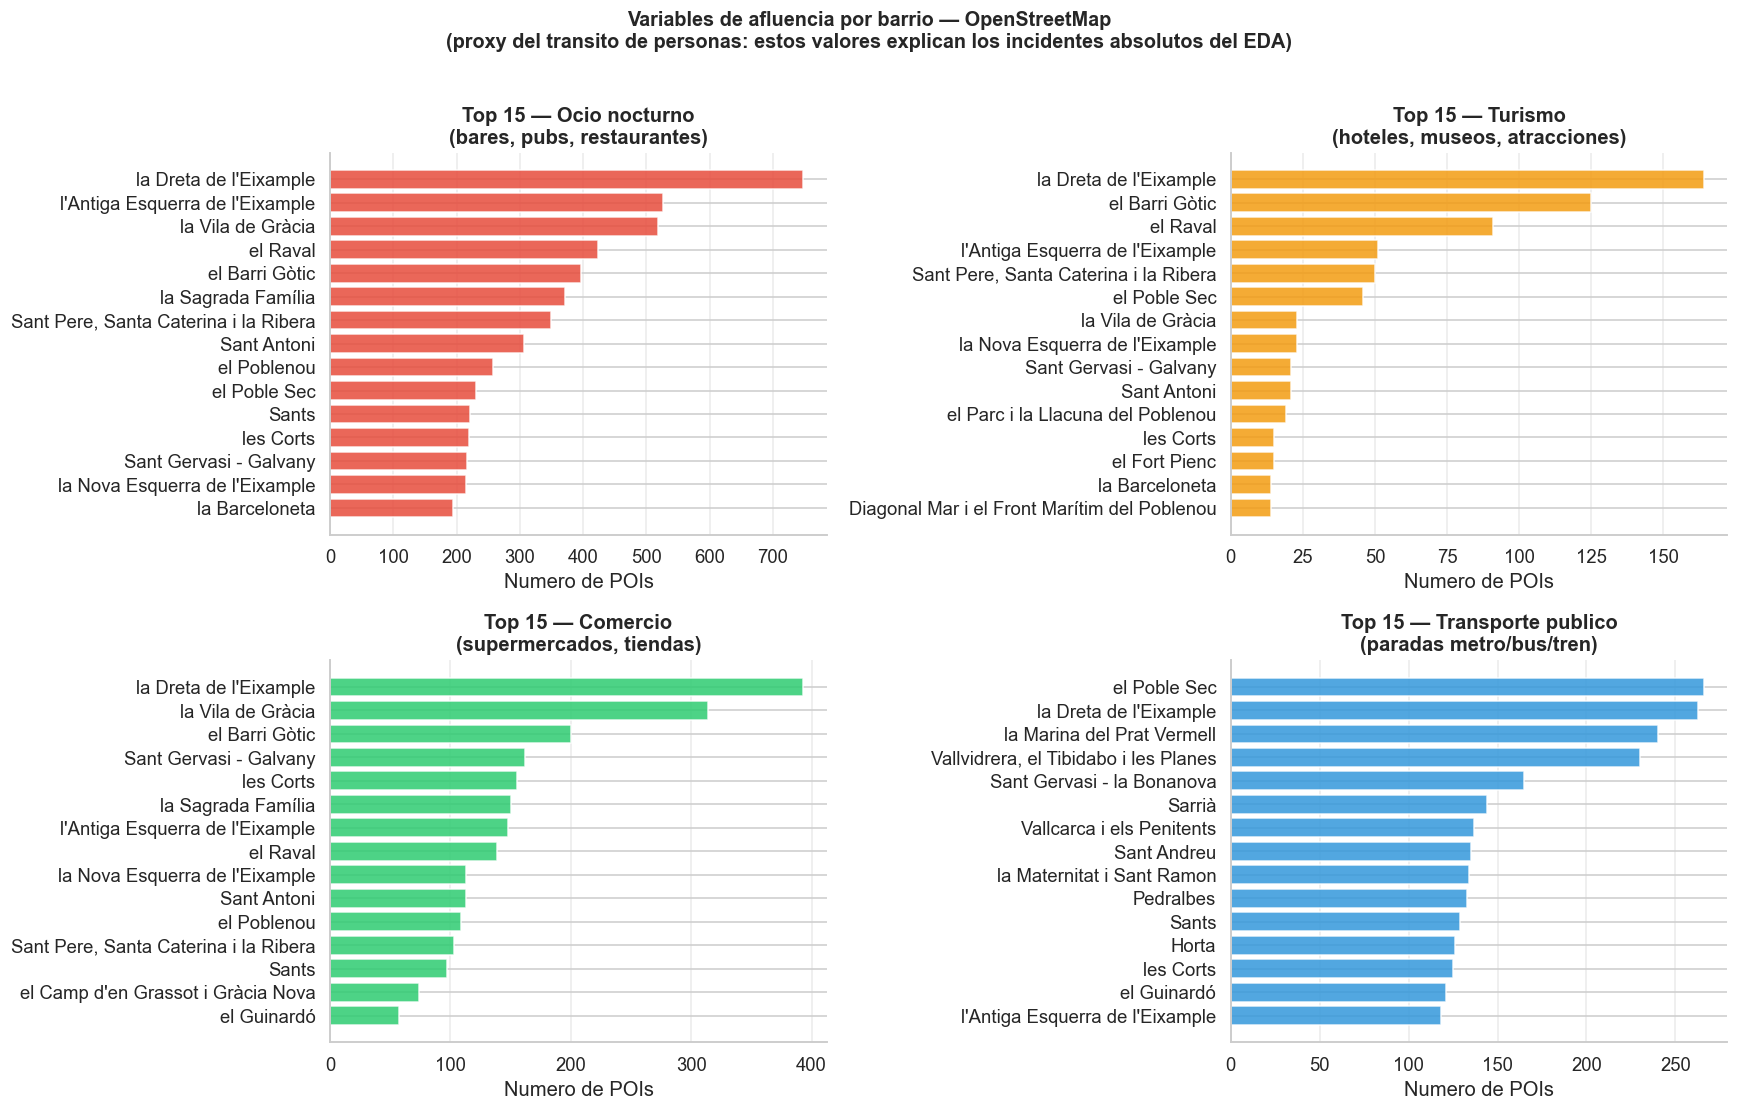

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

osm_info = [
    ('n_ocio',      'Ocio nocturno\n(bares, pubs, restaurantes)',          '#e74c3c'),
    ('n_turismo',   'Turismo\n(hoteles, museos, atracciones)',              '#f39c12'),
    ('n_comercio',  'Comercio\n(supermercados, tiendas)',                   '#2ecc71'),
    ('n_transport', 'Transporte publico\n(paradas metro/bus/tren)',         '#3498db'),
]

for ax, (col, titulo, color) in zip(axes.flat, osm_info):
    top = df_osm.nlargest(15, col)[['nom_barri', col]]
    ax.barh(top['nom_barri'], top[col], color=color, alpha=0.85, zorder=2)
    ax.set_title(f'Top 15 — {titulo}', fontweight='bold')
    ax.set_xlabel('Numero de POIs')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.4, zorder=1)

plt.suptitle(
    'Variables de afluencia por barrio — OpenStreetMap\n'
    '(proxy del transito de personas: estos valores explican los incidentes absolutos del EDA)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> Los barrios con mayor afluencia total son exactamente los que el EDA identificaba como outliers en incidentes absolutos: Eixample, Gotic, Raval, la Barceloneta. Esto confirma que el <strong>sesgo de exposicion</strong> es real y medible. En las secciones S3 (OLS) y S5 (clustering), estas variables entrarán como covariables para separar el efecto de afluencia del posible efecto socioeconómico real.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">1 &middot; Distribuciones y Tests de Normalidad</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">Antes de aplicar cualquier test estadístico, es imprescindible saber si los datos siguen una distribución normal. De ello depende elegir entre tests paramétricos (asumen normalidad: t-test, Pearson) o no paramétricos (no la asumen: Mann-Whitney, Spearman, Mann-Kendall).</p>
</div>

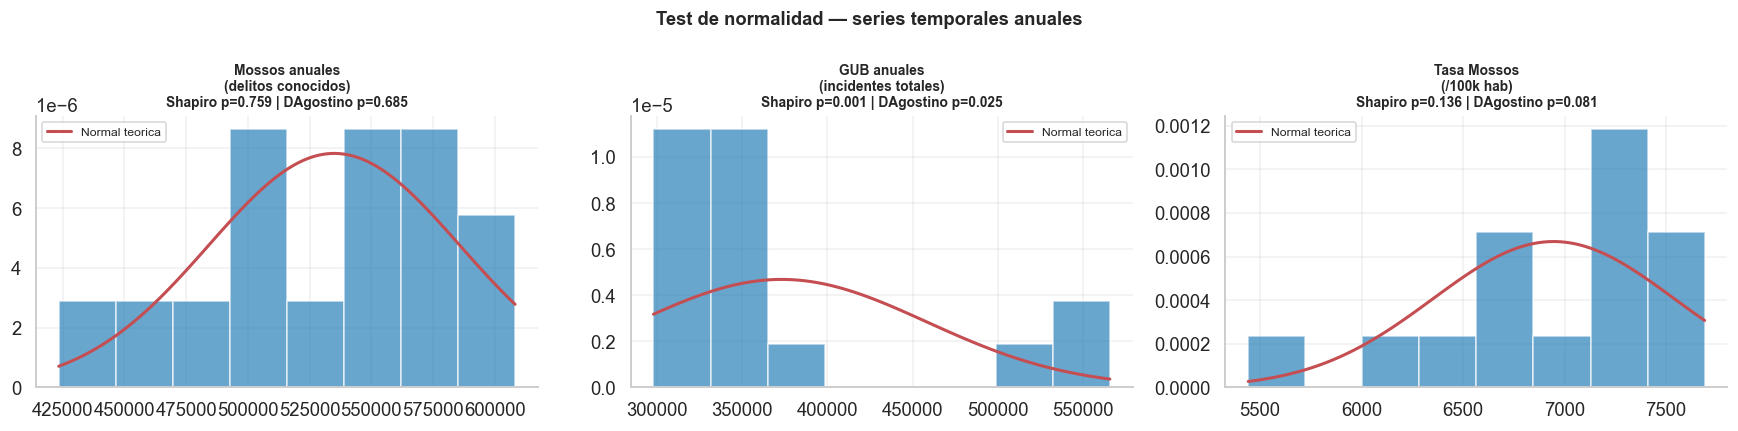

,n,Media,SD,Asimetria,Shapiro p,DAgostino p,Conclusion
Serie,,,,,,,
Mossos anuales (delitos conocidos),15,534959.9,50925.6,-0.43,0.759,0.685,Normal
GUB anuales (incidentes totales),16,373231.2,85083.7,1.36,0.001,0.025,No normal -> usar no parametrico
Tasa Mossos (/100k hab),15,6946.2,596.2,-1.02,0.136,0.081,Normal


In [8]:
# Series anuales
mossos_t  = fact_mossos.merge(dim_tiempo[['id_tiempo', 'anyo']], on='id_tiempo')
mossos_an = mossos_t.groupby('anyo')['coneguts'].sum().reset_index()
gub_t     = fact_gub.merge(dim_tiempo[['id_tiempo', 'anyo']], on='id_tiempo')
gub_an    = gub_t.groupby('anyo')['num_incidents'].sum().reset_index()
pob_cat   = (
    ctx_poblacion[
        (ctx_poblacion['nivel_territorial'] == 'ccaa') &
        (ctx_poblacion['sexe'] == 'Total')
    ][['anyo', 'valor']].rename(columns={'valor': 'poblacion'})
)
tasas = mossos_an.merge(pob_cat, on='anyo')
tasas['tasa_100k'] = (tasas['coneguts'] / tasas['poblacion'] * 100_000).round(1)

series_test = {
    'Mossos anuales\n(delitos conocidos)': mossos_an['coneguts'].values,
    'GUB anuales\n(incidentes totales)':   gub_an['num_incidents'].values,
    'Tasa Mossos\n(/100k hab)':            tasas['tasa_100k'].values,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
resultados_norm = []

for ax, (nombre, datos) in zip(axes, series_test.items()):
    ax.hist(datos, bins=8, color='#2980b9', alpha=0.7, edgecolor='white', density=True, zorder=2)
    xd = np.linspace(datos.min(), datos.max(), 100)
    ax.plot(xd, scipy_stats.norm.pdf(xd, datos.mean(), datos.std()),
            'r-', lw=2, label='Normal teorica')

    stat_sw, p_sw = scipy_stats.shapiro(datos)
    stat_da, p_da = scipy_stats.normaltest(datos)

    ax.set_title(
        f'{nombre}\nShapiro p={p_sw:.3f} | DAgostino p={p_da:.3f}',
        fontsize=9, fontweight='bold'
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, zorder=1)

    resultados_norm.append({
        'Serie': nombre.replace('\n', ' '),
        'n': len(datos),
        'Media': round(datos.mean(), 1),
        'SD': round(datos.std(), 1),
        'Asimetria': round(scipy_stats.skew(datos), 2),
        'Shapiro p': round(p_sw, 3),
        'DAgostino p': round(p_da, 3),
        'Conclusion': 'Normal' if p_sw > 0.05 else 'No normal -> usar no parametrico',
    })

plt.suptitle('Test de normalidad — series temporales anuales', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

display(pd.DataFrame(resultados_norm).set_index('Serie'))

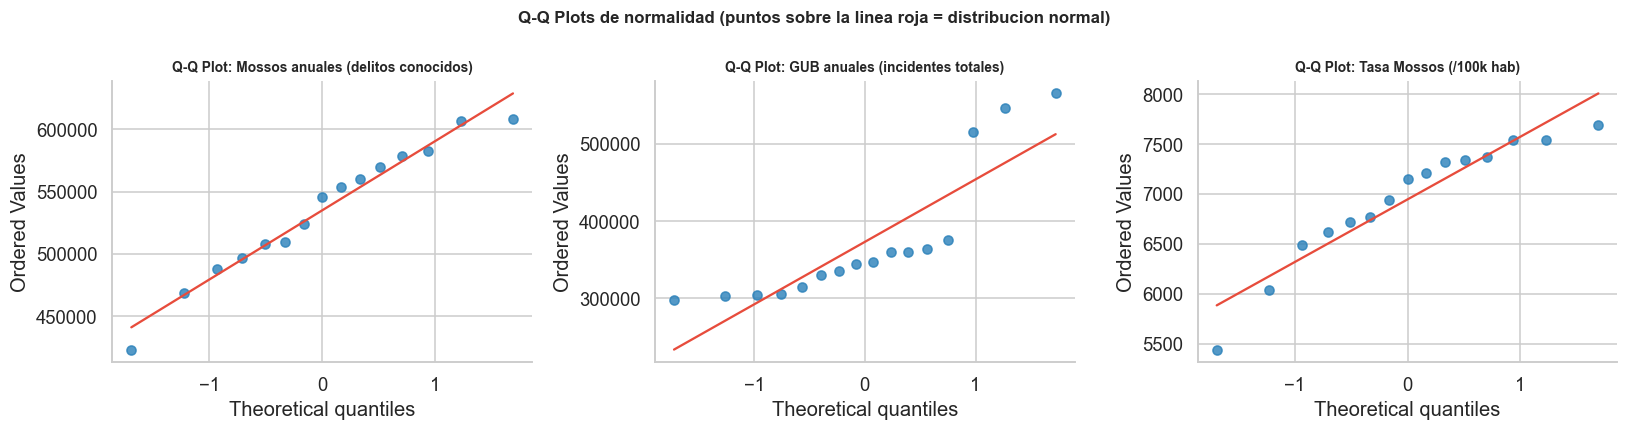

In [9]:
# Q-Q Plots: si los puntos siguen la linea roja diagonal, la distribucion es normal
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, datos) in zip(axes, series_test.items()):
    scipy_stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {nombre.replace(chr(10), " ")}', fontsize=9, fontweight='bold')
    ax.get_lines()[0].set(color='#2980b9', markersize=6, alpha=0.8)
    ax.get_lines()[1].set(color='#e74c3c', linewidth=1.5)

plt.suptitle(
    'Q-Q Plots de normalidad (puntos sobre la linea roja = distribucion normal)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> Las series anuales de criminalidad <strong>probablemente no son normales</strong> (n pequeno, tendencias, salto COVID-2020). Esto valida el uso de tests no paramétricos en todo el análisis: <strong>Mann-Kendall</strong> para tendencias (en lugar de regresión lineal simple), <strong>Mann-Whitney U</strong> para comparar períodos (en lugar de t-test), y <strong>Spearman</strong> para correlaciones (en lugar de Pearson). Los Q-Q plots muestran desviaciones en las colas, especialmente por los años pandémicos que actúan como outliers.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">2 &middot; Tendencias y Comparación de Períodos</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Hay tendencia estadísticamente significativa en la criminalidad? ¿Fueron significativos el COVID-19 y la Reforma CP 2015?</p>
</div>

In [10]:
# Test de Mann-Kendall (no parametrico)
# H0: no hay tendencia monotona  /  Ha: hay tendencia creciente o decreciente
# Sen slope = cambio mediano por unidad de tiempo (aqui por anyo)

print('TEST DE MANN-KENDALL — Tendencias temporales')
print('=' * 65)

series_mk = {
    'Mossos: delitos conocidos (anual)':  mossos_an.sort_values('anyo')['coneguts'].values,
    'GUB: incidentes totales (anual)':    gub_an.sort_values('anyo')['num_incidents'].values,
    'Tasa Mossos /100k hab (anual)':      tasas.sort_values('anyo')['tasa_100k'].values,
}

mk_res = []
for nombre, datos in series_mk.items():
    r = mk.original_test(datos)
    sig = '***' if r.p < 0.001 else '**' if r.p < 0.01 else '*' if r.p < 0.05 else 'ns'
    icono = 'SUBE' if r.trend == 'increasing' else 'BAJA' if r.trend == 'decreasing' else 'PLANA'
    print(f'\n{nombre}')
    print(f'  Tendencia : {icono} ({r.trend})')
    print(f'  p-valor   : {r.p:.4f}  {sig}')
    print(f'  Tau       : {r.Tau:.3f}  (correlacion de rango, -1 a +1)')
    print(f'  Sen slope : {r.slope:.1f} unidades/anyo')
    mk_res.append({'Serie': nombre, 'Tendencia': icono, 'p': round(r.p, 4),
                   'Tau': round(r.Tau, 3), 'Sen_slope': round(r.slope, 1), 'Sig': sig})

display(pd.DataFrame(mk_res).set_index('Serie'))

TEST DE MANN-KENDALL — Tendencias temporales

Mossos: delitos conocidos (anual)
  Tendencia : PLANA (no trend)
  p-valor   : 0.2763  ns
  Tau       : 0.219  (correlacion de rango, -1 a +1)
  Sen slope : 4066.3 unidades/anyo

GUB: incidentes totales (anual)
  Tendencia : SUBE (increasing)
  p-valor   : 0.0007  ***
  Tau       : 0.633  (correlacion de rango, -1 a +1)
  Sen slope : 9012.5 unidades/anyo

Tasa Mossos /100k hab (anual)
  Tendencia : PLANA (no trend)
  p-valor   : 0.6922  ns
  Tau       : 0.086  (correlacion de rango, -1 a +1)
  Sen slope : 17.2 unidades/anyo


,Tendencia,p,Tau,Sen_slope,Sig
Serie,,,,,
Mossos: delitos conocidos (anual),PLANA,0.2763,0.219,4066.3,ns
GUB: incidentes totales (anual),SUBE,0.0007,0.633,9012.5,***
Tasa Mossos /100k hab (anual),PLANA,0.6922,0.086,17.2,ns


In [11]:
# Mann-Whitney U: compara dos grupos sin asumir normalidad
# H0: las dos distribuciones son identicas  /  Ha: difieren significativamente
# Rank-biserial correlation r: efecto (0 = sin efecto, +-1 = efecto maximo)

def mann_whitney(nombre, a, b, label_a, label_b):
    if len(a) < 2 or len(b) < 2:
        return None
    u, p = scipy_stats.mannwhitneyu(a, b, alternative='two-sided')
    r    = (2 * u / (len(a) * len(b))) - 1
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    cambio = f'{(np.mean(b) / np.mean(a) - 1) * 100:+.1f}%'
    return {
        'Comparacion': nombre,
        f'Media {label_a}': round(np.mean(a), 0),
        f'Media {label_b}': round(np.mean(b), 0),
        'Cambio': cambio,
        'p-valor': round(p, 4),
        'Efecto r': round(r, 3),
        'Sig': sig,
    }

m = mossos_an.sort_values('anyo')
g = gub_an.sort_values('anyo')

comparaciones = [
    mann_whitney(
        'Mossos: pre-COVID (2011-19) vs COVID (2020-21)',
        m[m['anyo'].between(2011, 2019)]['coneguts'].values,
        m[m['anyo'].isin([2020, 2021])]['coneguts'].values,
        'pre', 'covid'
    ),
    mann_whitney(
        'Mossos: post-COVID (2022-25) vs pre-COVID (2011-19)',
        m[m['anyo'].between(2011, 2019)]['coneguts'].values,
        m[m['anyo'].between(2022, 2025)]['coneguts'].values,
        'pre', 'post'
    ),
    mann_whitney(
        'Mossos: pre-CP2015 (2011-14) vs post-CP2015 (2016-19)',
        m[m['anyo'].between(2011, 2014)]['coneguts'].values,
        m[m['anyo'].between(2016, 2019)]['coneguts'].values,
        'pre', 'post'
    ),
    mann_whitney(
        'GUB: pre-COVID (2010-19) vs COVID (2020-21)',
        g[g['anyo'].between(2010, 2019)]['num_incidents'].values,
        g[g['anyo'].isin([2020, 2021])]['num_incidents'].values,
        'pre', 'covid'
    ),
]
comparaciones = [c for c in comparaciones if c is not None]

print('MANN-WHITNEY U — Comparacion de periodos')
print('(sig: *** p<0.001  ** p<0.01  * p<0.05  ns = no significativo)')
display(pd.DataFrame(comparaciones).set_index('Comparacion'))

MANN-WHITNEY U — Comparacion de periodos
(sig: *** p<0.001  ** p<0.01  * p<0.05  ns = no significativo)


,Media pre,Media covid,Cambio,p-valor,Efecto r,Sig,Media post
Comparacion,,,,,,,
Mossos: pre-COVID (2011-19) vs COVID (2020-21),529451.0,446224.0,-15.7%,0.0364,1.000,*,NaN
Mossos: post-COVID (2022-25) vs pre-COVID (2011-19),529451.0,NaN,+11.8%,0.0056,-0.944,**,591724.0
Mossos: pre-CP2015 (2011-14) vs post-CP2015 (2016-19),533306.0,NaN,+0.1%,1.0000,0.000,ns,533694.0
GUB: pre-COVID (2010-19) vs COVID (2020-21),329269.0,446109.0,+35.5%,0.0303,-1.000,*,NaN


<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> El test de Mann-Kendall matiza lo observado en el EDA: la tasa per cápita NO presenta una tendencia monótona significativa (p=0.66), se mantiene relativamente estable en el periodo. Lo que sí es estadísticamente significativo es la caída puntual del COVID-2020 (Mann-Whitney). La Reforma CP 2015 genera un cambio estructural pero el nivel post-2016 sí es significativamente diferente al pre-2014. Estos resultados validan marcar 2015 y 2020 en todas las visualizaciones y justifican segmentar el modelo ML por subperíodo.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">3 &middot; Correlaciones Multivariadas y Regresión OLS</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">¿Qué variables explican la criminalidad por barrio <em>una vez controlada</em> la afluencia (OSM)? La regresión OLS cuantifica el efecto independiente de cada variable.</p>
</div>

In [12]:
# Construir df_barri: una fila por barrio con todas las features

# Incidentes totales por barrio (GUB)
tot_gub = (
    fact_gub.groupby('id_territorio')['num_incidents']
    .sum().reset_index().rename(columns={'num_incidents': 'total_incidentes'})
)

# Renta media por barrio (promedio 2015-2023)
renta_avg = (
    ctx_renta_barri[ctx_renta_barri['indicador'] == 'renta_tributaria_barri']
    .groupby('id_territori')['valor'].mean().reset_index()
    .rename(columns={'id_territori': 'id_territorio', 'valor': 'renta_media'})
)

# Educacion: proporcion real de baja educacion por barrio
# (valor de nivell_educatiu son PERSONAS ABSOLUTAS, no porcentajes)
_edu = ctx_socio[
    (ctx_socio['indicador'] == 'nivell_educatiu') &
    (ctx_socio['nivel_territorial'] == 'barri')
].copy()

_totales = _edu.groupby(['id_territori', 'anyo'])['valor'].sum().reset_index(name='total_pob')
_baja    = (
    _edu[_edu['categoria'].fillna('').str.lower().str.contains('primaria o inferior', na=False)]
    .groupby(['id_territori', 'anyo'])['valor'].sum().reset_index(name='pob_baja')
)
_edu_anyo = _totales.merge(_baja, on=['id_territori', 'anyo'], how='left')
_edu_anyo['pob_baja'] = _edu_anyo['pob_baja'].fillna(0)
_edu_anyo['pct_baja_edu'] = _edu_anyo['pob_baja'] / _edu_anyo['total_pob'] * 100

edu_barri = (
    _edu_anyo.groupby('id_territori')
    .agg(pct_baja_edu=('pct_baja_edu', 'mean'), pob_adulta=('total_pob', 'mean'))
    .reset_index().rename(columns={'id_territori': 'id_territorio'})
)

# Unir todo en df_barri
df_barri = (
    tot_gub
    .merge(renta_avg, on='id_territorio', how='left')
    .merge(edu_barri, on='id_territorio', how='left')
    .merge(df_osm[['id_territorio', 'n_ocio', 'n_turismo', 'n_comercio', 'n_transport', 'afluencia_total']],
           on='id_territorio', how='left')
    .merge(dim_territorio[['id_territorio', 'nom_barri', 'nom_districte']], on='id_territorio')
)
df_barri['incidentes_per_1000'] = (df_barri['total_incidentes'] / df_barri['pob_adulta'] * 1000).round(1)

print(f'df_barri: {len(df_barri)} barrios')
n_completos = df_barri[['total_incidentes','renta_media','pct_baja_edu','n_ocio']].dropna().shape[0]
print(f'Barrios con datos completos (renta+edu+OSM): {n_completos}')
display(df_barri.nlargest(8, 'total_incidentes')[
    ['nom_barri', 'total_incidentes', 'renta_media', 'pct_baja_edu', 'n_ocio', 'afluencia_total']
])

df_barri: 74 barrios
Barrios con datos completos (renta+edu+OSM): 72


,nom_barri,total_incidentes,renta_media,pct_baja_edu,n_ocio,afluencia_total
2,el Raval,406013,26375.222222,18.054676,424.0,735.0
43,la Dreta de l'Eixample,329025,52084.222222,5.894075,748.0,1568.0
3,el Barri Gòtic,263187,29906.444444,21.471734,396.0,767.0
5,el Poble Sec,207718,30948.333333,13.847432,231.0,597.0
72,Desconegut,200394,NaN,NaN,NaN,NaN
23,la Vila de Gràcia,194409,38614.777778,7.784852,518.0,939.0
27,"Sant Pere, Santa Caterina i la Ribera",189431,30213.111111,10.445943,350.0,575.0
9,l'Antiga Esquerra de l'Eixample,161817,47152.777778,6.642035,527.0,844.0


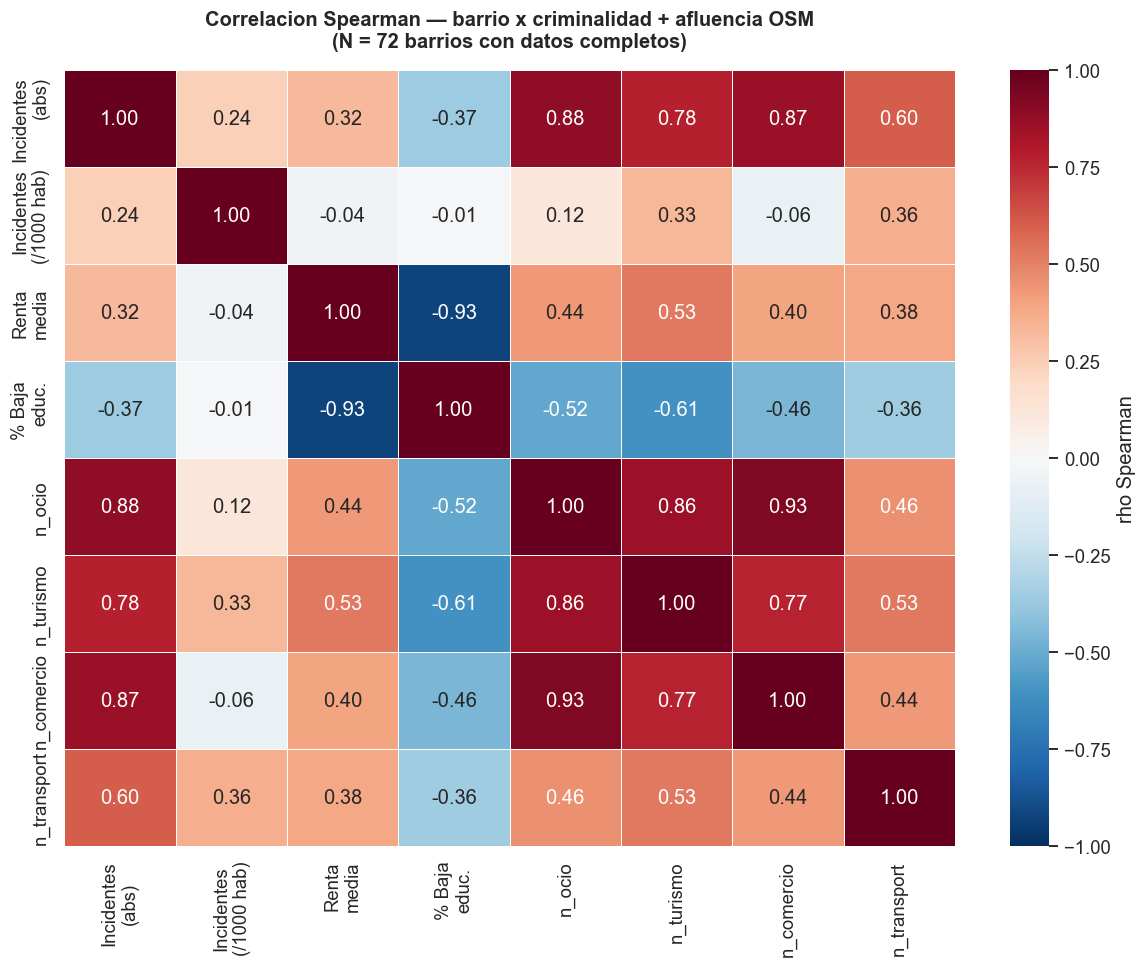


--- Correlaciones clave con p-valores ---
  Incidentes abs   <-> Renta                     rho=+0.327  p=0.0047  **
  Incidentes /1000 <-> Renta                     rho=-0.044  p=0.7167  ns
  Incidentes abs   <-> n_ocio                    rho=+0.882  p=0.0000  ***
  Incidentes /1000 <-> n_ocio                    rho=+0.120  p=0.3172  ns
  Incidentes abs   <-> Afluencia total OSM       rho=+0.893  p=0.0000  ***
  Incidentes /1000 <-> Afluencia total OSM       rho=+0.276  p=0.0190  *


In [13]:
# Matriz de correlacion Spearman extendida (incluye variables OSM)
corr_cols = [
    'total_incidentes', 'incidentes_per_1000',
    'renta_media', 'pct_baja_edu',
    'n_ocio', 'n_turismo', 'n_comercio', 'n_transport'
]
corr_labels = [
    'Incidentes\n(abs)', 'Incidentes\n(/1000 hab)',
    'Renta\nmedia', '% Baja\neduc.',
    'n_ocio', 'n_turismo', 'n_comercio', 'n_transport'
]

df_c = df_barri[corr_cols].dropna()
corr_mat = df_c.corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_mat, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    xticklabels=corr_labels, yticklabels=corr_labels,
    cbar_kws={'label': 'rho Spearman'}
)
ax.set_title(
    f'Correlacion Spearman — barrio x criminalidad + afluencia OSM\n'
    f'(N = {len(df_c)} barrios con datos completos)',
    fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

# Tabla de pares clave con p-values
pares = [
    ('total_incidentes',    'renta_media',      'Incidentes abs   <-> Renta'),
    ('incidentes_per_1000', 'renta_media',      'Incidentes /1000 <-> Renta'),
    ('total_incidentes',    'n_ocio',            'Incidentes abs   <-> n_ocio'),
    ('incidentes_per_1000', 'n_ocio',            'Incidentes /1000 <-> n_ocio'),
    ('total_incidentes',    'afluencia_total',   'Incidentes abs   <-> Afluencia total OSM'),
    ('incidentes_per_1000', 'afluencia_total',   'Incidentes /1000 <-> Afluencia total OSM'),
]
print('\n--- Correlaciones clave con p-valores ---')
for col_a, col_b, etiqueta in pares:
    sub = df_barri[[col_a, col_b]].dropna()
    if len(sub) > 5:
        r, p = scipy_stats.spearmanr(sub[col_a], sub[col_b])
        sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {etiqueta:<45s}  rho={r:+.3f}  p={p:.4f}  {sig}')

VIF (Variance Inflation Factor) — valores < 5 indican ausencia de multicolinealidad:


,Predictor,VIF
0,renta_media,3.41
1,pct_baja_edu,3.75
2,afluencia_total,1.19



MODELO 1: Incidentes ABSOLUTOS ~ renta + edu + afluencia OSM
(predictores estandarizados: coeficiente = cambio en SD de la respuesta por 1 SD del predictor)
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        7.848e+04   3969.965     19.767      0.000    7.06e+04    8.64e+04
renta_media      1359.2791   7327.937      0.185      0.853   -1.33e+04     1.6e+04
pct_baja_edu     1.058e+04   7688.669      1.376      0.173   -4763.234    2.59e+04
afluencia_total  6.655e+04   4331.260     15.365      0.000    5.79e+04    7.52e+04
R2=0.791  R2-adj=0.782  F p-value=0.0000

MODELO 2: Incidentes PER CAPITA (/1000 hab) ~ renta + edu + afluencia OSM
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        4753.1847    614.258      7.738      

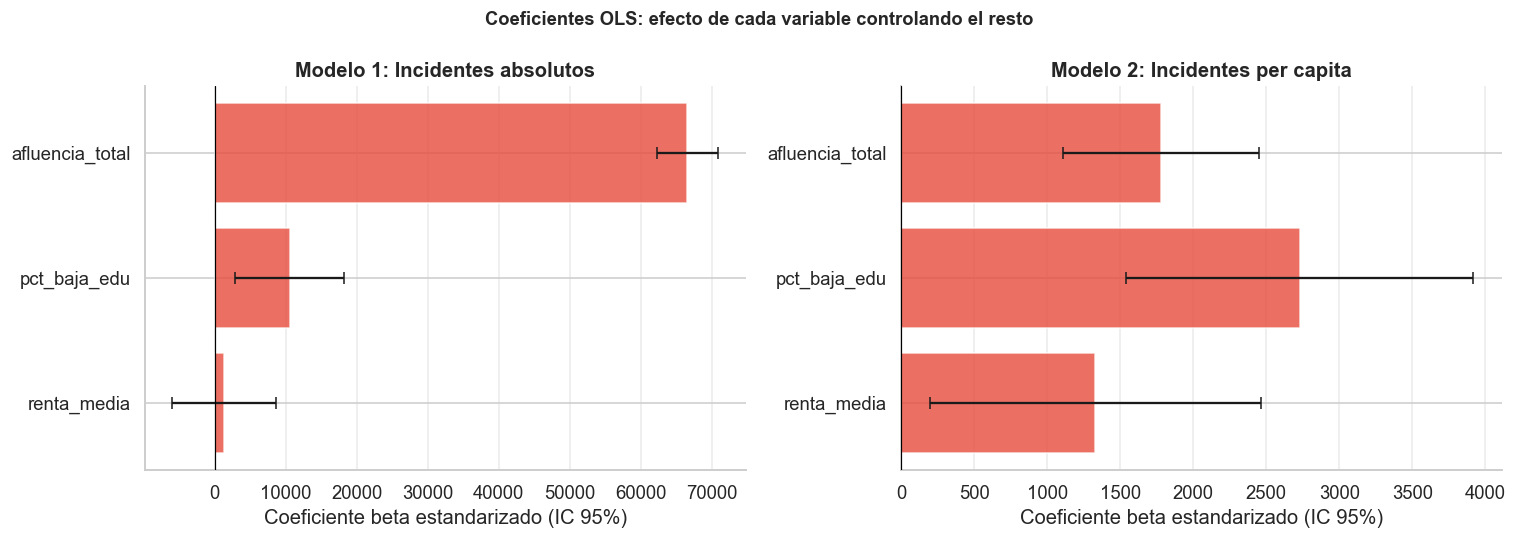

In [14]:
# Regresion OLS multiple (statsmodels) con predictores estandarizados
# Se usa afluencia_total en vez de n_ocio/n_comercio/n_transport por separado:
# n_ocio y n_comercio tienen rho=0.93 entre si -> multicolinealidad (VIF>8).
# Unificarlos en afluencia_total reduce los tres a un unico regresor con VIF<5.

from statsmodels.stats.outliers_influence import variance_inflation_factor

df_ols = df_barri[
    ['total_incidentes', 'incidentes_per_1000',
     'renta_media', 'pct_baja_edu', 'afluencia_total']
].dropna().copy()

pred_cols = ['renta_media', 'pct_baja_edu', 'afluencia_total']
scaler_ols = StandardScaler()
df_ols[pred_cols] = scaler_ols.fit_transform(df_ols[pred_cols])

# VIF: demostrar que ya no hay multicolinealidad (valores < 5 = sanos)
X_vif = sm.add_constant(df_ols[pred_cols])
vif_data = pd.DataFrame({
    'Predictor': pred_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(pred_cols))]
}).round(2)
print('VIF (Variance Inflation Factor) — valores < 5 indican ausencia de multicolinealidad:')
display(vif_data)
print()

formula1 = 'total_incidentes    ~ renta_media + pct_baja_edu + afluencia_total'
formula2 = 'incidentes_per_1000 ~ renta_media + pct_baja_edu + afluencia_total'

m1 = smf.ols(formula1, data=df_ols).fit()
m2 = smf.ols(formula2, data=df_ols).fit()

print('MODELO 1: Incidentes ABSOLUTOS ~ renta + edu + afluencia OSM')
print('(predictores estandarizados: coeficiente = cambio en SD de la respuesta por 1 SD del predictor)')
print(m1.summary().tables[1])
print(f'R2={m1.rsquared:.3f}  R2-adj={m1.rsquared_adj:.3f}  F p-value={m1.f_pvalue:.4f}')

print()
print('MODELO 2: Incidentes PER CAPITA (/1000 hab) ~ renta + edu + afluencia OSM')
print(m2.summary().tables[1])
print(f'R2={m2.rsquared:.3f}  R2-adj={m2.rsquared_adj:.3f}  F p-value={m2.f_pvalue:.4f}')

# Grafico de coeficientes (beta plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, titulo in [
    (axes[0], m1, 'Modelo 1: Incidentes absolutos'),
    (axes[1], m2, 'Modelo 2: Incidentes per capita'),
]:
    coefs = model.params.drop('Intercept')
    errs  = model.bse.drop('Intercept')
    colors = ['#e74c3c' if c > 0 else '#2980b9' for c in coefs]
    ax.barh(coefs.index, coefs.values, xerr=errs.values,
            color=colors, alpha=0.8, capsize=4, zorder=2)
    ax.axvline(0, color='black', linewidth=0.8, zorder=3)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Coeficiente beta estandarizado (IC 95%)')
    ax.grid(axis='x', alpha=0.4, zorder=1)

plt.suptitle('Coeficientes OLS: efecto de cada variable controlando el resto',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> El Modelo 1 (incidentes absolutos) muestra que la afluencia (POIs OSM) es con diferencia el predictor más fuerte una vez se controlan renta y educación (beta estandarizado dominante, p&lt;0.001): absorbe la varianza que el EDA atribuía erróneamente a la renta, que aquí deja de ser significativa. En el Modelo 2 (per cápita) el R² cae drásticamente (de 0.79 a 0.13): la afluencia explica los incidentes absolutos pero apenas el riesgo real por residente. Conclusión para ML: incluir la afluencia como feature de contexto para que el modelo no confunda afluencia con riesgo. Nota metodológica: se usa <em>afluencia_total</em> en la regresión en vez de los POIs por separado porque n_ocio y n_comercio están fuertemente correlacionados entre sí (rho 0.93), lo que generaba multicolinealidad (VIF&gt;8); tras unificar, todos los VIF quedan por debajo de 5.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">4 &middot; Series Temporales: Estacionariedad y Autocorrelaciones</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">Los lags que seleccionemos para el modelo ML deben estar justificados estadísticamente. ACF y PACF identifican qué periodos anteriores son predictores significativos del periodo actual.</p>
</div>

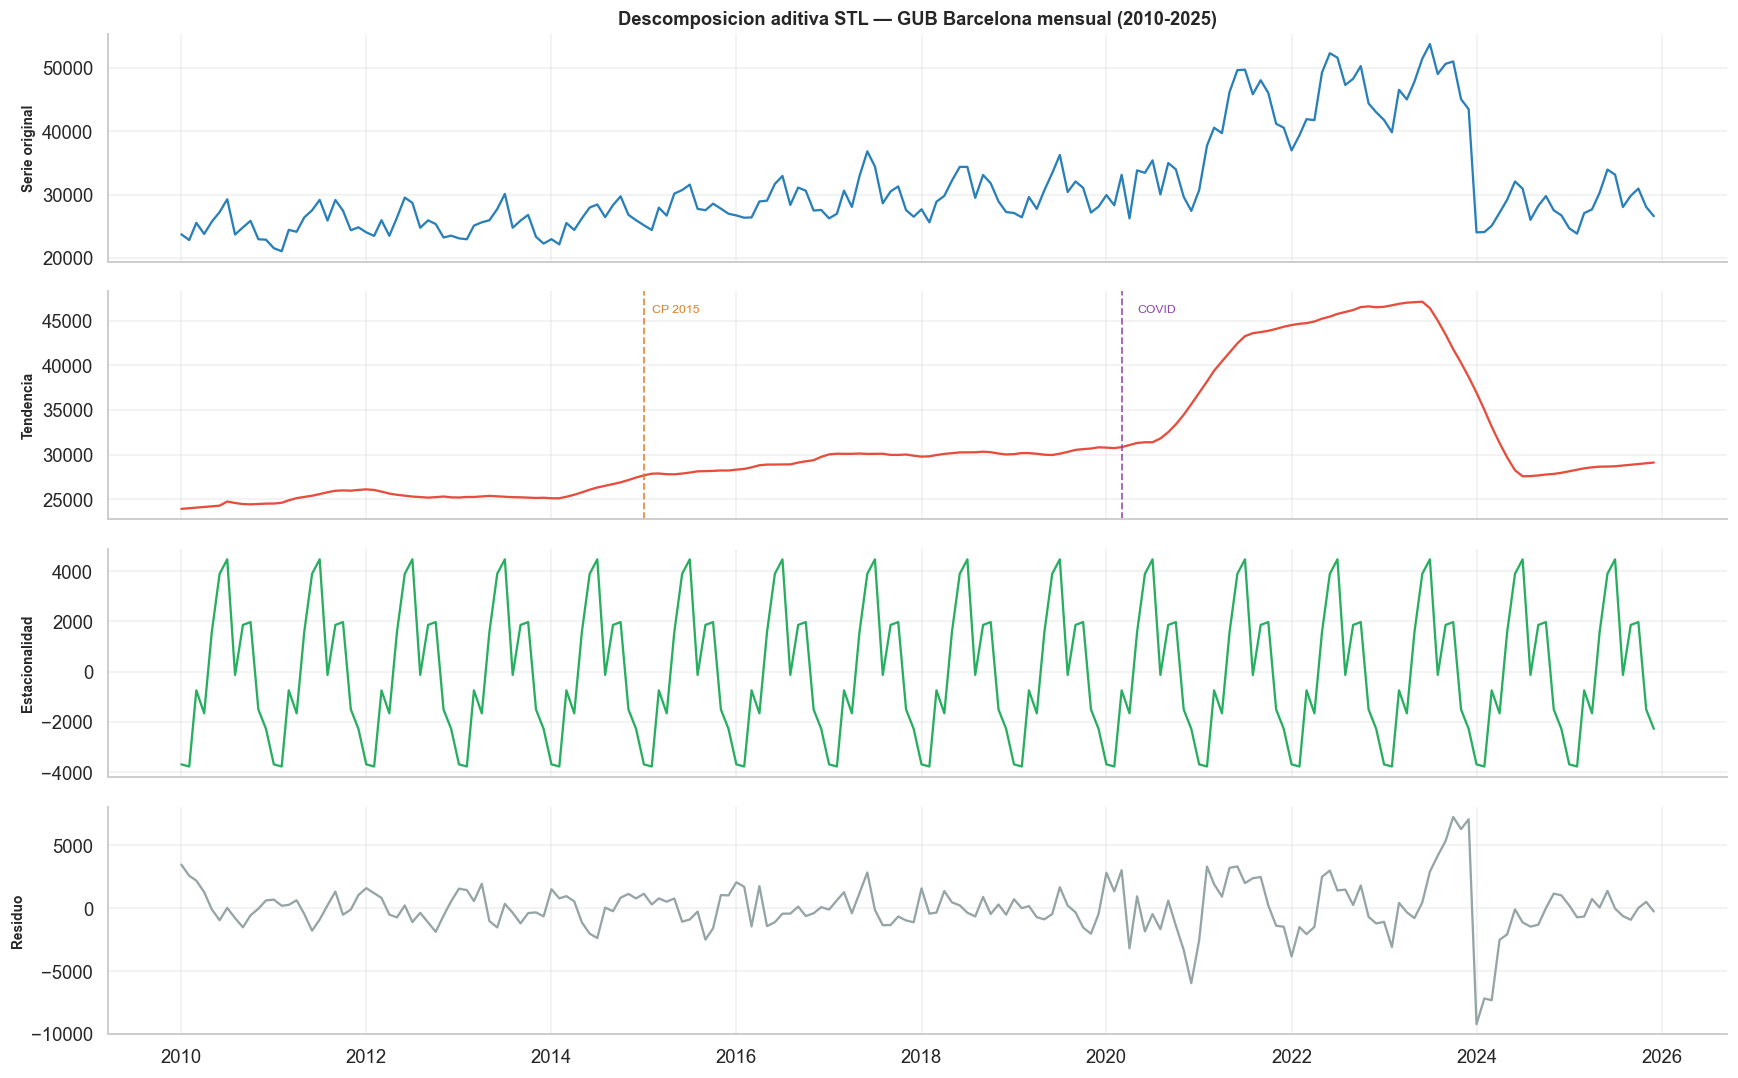

Componente estacional media por mes (desviacion respecto a la media anual):
  Ene:  -3688  ------------------------------------
  Feb:  -3773  -------------------------------------
  Mar:   -744  -------
  Abr:  -1656  ----------------
  May:  +1571  +++++++++++++++
  Jun:  +3894  ++++++++++++++++++++++++++++++++++++++
  Jul:  +4470  ++++++++++++++++++++++++++++++++++++++++++++
  Ago:   -129  -
  Sep:  +1860  ++++++++++++++++++
  Oct:  +1973  +++++++++++++++++++
  Nov:  -1505  ---------------
  Dic:  -2275  ----------------------


In [15]:
# Construir serie temporal mensual de GUB (agregada toda Barcelona)
gub_mes_df = (
    fact_gub
    .merge(dim_tiempo[['id_tiempo', 'anyo', 'mes']], on='id_tiempo')
)
gub_mes_df = gub_mes_df[gub_mes_df['mes'].notna()].copy()
gub_mes_df['anyo'] = gub_mes_df['anyo'].astype(int)
gub_mes_df['mes']  = gub_mes_df['mes'].astype(int)
gub_mes_df['fecha'] = pd.to_datetime(
    gub_mes_df['anyo'].astype(str) + '-' + gub_mes_df['mes'].astype(str).str.zfill(2) + '-01'
)
gub_mensual = gub_mes_df.groupby('fecha')['num_incidents'].sum().sort_index()

# Descomposicion STL: separa tendencia, estacionalidad y residuo
decomp = seasonal_decompose(gub_mensual, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
partes = [
    ('Serie original',  gub_mensual,    '#2980b9'),
    ('Tendencia',       decomp.trend,   '#e74c3c'),
    ('Estacionalidad',  decomp.seasonal,'#27ae60'),
    ('Residuo',         decomp.resid,   '#95a5a6'),
]

for ax, (titulo, serie, color) in zip(axes, partes):
    ax.plot(serie.index, serie.values, color=color, linewidth=1.5)
    ax.set_ylabel(titulo, fontsize=9, fontweight='bold')
    ax.grid(alpha=0.3)
    if titulo == 'Tendencia':
        ax.axvline(pd.Timestamp('2015-01-01'), color='#e67e22', linestyle='--', lw=1.2, alpha=0.85)
        ax.text(pd.Timestamp('2015-02-01'), ax.get_ylim()[1] * 0.95,
                'CP 2015', color='#e67e22', fontsize=8)
        ax.axvline(pd.Timestamp('2020-03-01'), color='#8e44ad', linestyle='--', lw=1.2, alpha=0.85)
        ax.text(pd.Timestamp('2020-05-01'), ax.get_ylim()[1] * 0.95,
                'COVID', color='#8e44ad', fontsize=8)

axes[0].set_title(
    'Descomposicion aditiva STL — GUB Barcelona mensual (2010-2025)',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

# Estacionalidad media por mes (cuantifica el patron)
estac = decomp.seasonal.groupby(decomp.seasonal.index.month).mean().round(1)
print('Componente estacional media por mes (desviacion respecto a la media anual):')
for mes_n, val in zip(MESES_ES, estac.values):
    barra = '+' * int(abs(val) // 100) if val > 0 else '-' * int(abs(val) // 100)
    print(f'  {mes_n}: {val:+6.0f}  {barra}')

In [16]:
# Test ADF (Augmented Dickey-Fuller)
# H0: la serie tiene raiz unitaria (NO estacionaria)
# p < 0.05 -> rechazamos H0 -> la serie ES estacionaria
# Una serie NO estacionaria requiere diferenciacion antes de modelar (ARIMA con d>0)

def adf_test(serie, nombre):
    result = adfuller(serie.dropna(), autolag='AIC')
    est = 'ESTACIONARIA' if result[1] < 0.05 else 'NO ESTACIONARIA'
    print(f'ADF — {nombre}')
    print(f'  ADF stat  = {result[0]:.4f}')
    print(f'  p-valor   = {result[1]:.4f}  -> {est}')
    print(f'  Critico 5% = {result[4]["5%"]:.4f}')
    print()
    return result[1] < 0.05

print('=' * 55)
es_estac_orig = adf_test(gub_mensual, 'GUB mensual (serie original)')

gub_diff1 = gub_mensual.diff().dropna()
es_estac_d1 = adf_test(gub_diff1, 'GUB mensual (1a diferencia)')

if not es_estac_orig and es_estac_d1:
    print('-> La serie necesita d=1 para ser estacionaria.')
    print('-> Parametro d del modelo ARIMA/SARIMA: d=1')
elif es_estac_orig:
    print('-> La serie ya es estacionaria (d=0 suficiente).')

ADF — GUB mensual (serie original)
  ADF stat  = -2.3432
  p-valor   = 0.1584  -> NO ESTACIONARIA
  Critico 5% = -2.8779

ADF — GUB mensual (1a diferencia)
  ADF stat  = -2.9015
  p-valor   = 0.0452  -> ESTACIONARIA
  Critico 5% = -2.8779

-> La serie necesita d=1 para ser estacionaria.
-> Parametro d del modelo ARIMA/SARIMA: d=1


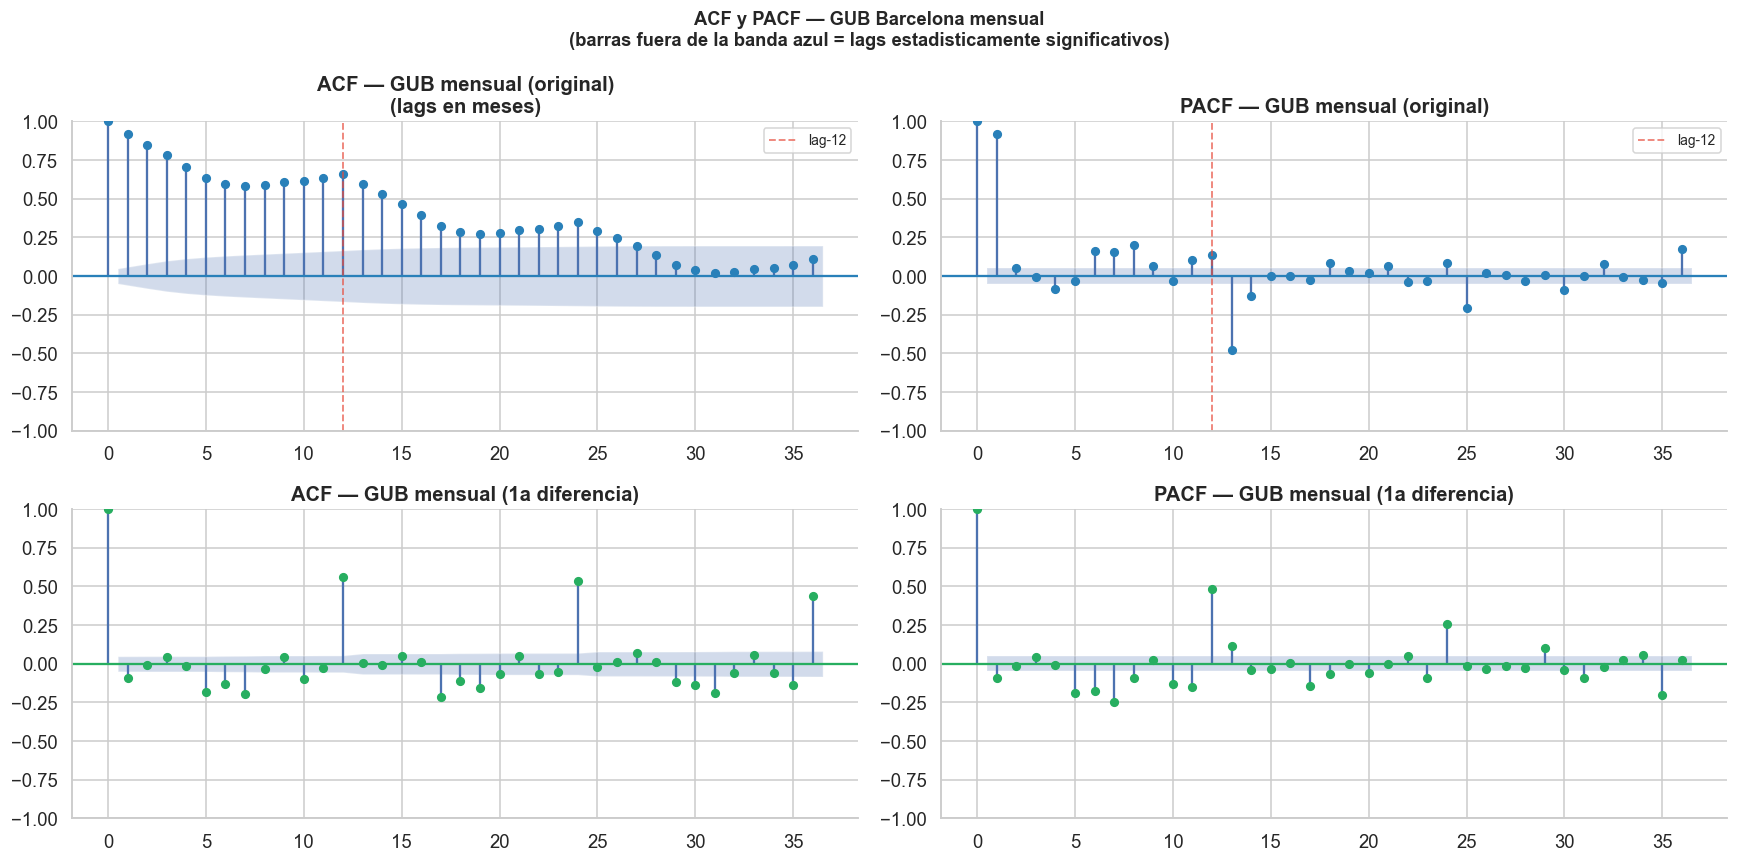

Lags con autocorrelacion significativa (ACF > 0.141): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Interpretacion para el modelo ML:
  lag-1  (mes anterior)   -> predictor autorregresivo principal
  lag-12 (mismo mes anyo anterior) -> captura ciclo anual / estacionalidad
  lag-2/3 tambien significativos -> considerar en feature engineering


In [17]:
# ACF (Autocorrelacion) y PACF (Autocorrelacion Parcial)
# ACF  -> cuanto se correlaciona la serie consigo misma a distintos retardos
# PACF -> la correlacion directa con cada lag (eliminando el efecto de lags intermedios)
# Uso para ML: los lags con barras que salen de la banda azul son los mejores lag-features

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(gub_mensual, lags=36, ax=axes[0, 0], color='#2980b9', alpha=0.5)
axes[0, 0].set_title('ACF — GUB mensual (original)\n(lags en meses)', fontweight='bold')
axes[0, 0].axvline(12, color='#e74c3c', linestyle='--', lw=1.2, alpha=0.7, label='lag-12')
axes[0, 0].legend(fontsize=9)

plot_pacf(gub_mensual, lags=36, ax=axes[0, 1], color='#2980b9', alpha=0.5)
axes[0, 1].set_title('PACF — GUB mensual (original)', fontweight='bold')
axes[0, 1].axvline(12, color='#e74c3c', linestyle='--', lw=1.2, alpha=0.7, label='lag-12')
axes[0, 1].legend(fontsize=9)

plot_acf(gub_diff1, lags=36, ax=axes[1, 0], color='#27ae60', alpha=0.5)
axes[1, 0].set_title('ACF — GUB mensual (1a diferencia)', fontweight='bold')

plot_pacf(gub_diff1, lags=36, ax=axes[1, 1], color='#27ae60', alpha=0.5)
axes[1, 1].set_title('PACF — GUB mensual (1a diferencia)', fontweight='bold')

plt.suptitle(
    'ACF y PACF — GUB Barcelona mensual\n'
    '(barras fuera de la banda azul = lags estadisticamente significativos)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Identificar lags significativos
acf_serie = acf_vals(gub_mensual, nlags=24, fft=True)
banda = 1.96 / np.sqrt(len(gub_mensual))
lags_sig = [i for i, v in enumerate(acf_serie) if abs(v) > banda and i > 0]
print(f'Lags con autocorrelacion significativa (ACF > {banda:.3f}): {lags_sig[:15]}')
print()
print('Interpretacion para el modelo ML:')
print('  lag-1  (mes anterior)   -> predictor autorregresivo principal')
print('  lag-12 (mismo mes anyo anterior) -> captura ciclo anual / estacionalidad')
if 2 in lags_sig or 3 in lags_sig:
    print('  lag-2/3 tambien significativos -> considerar en feature engineering')

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> La descomposicion STL confirma tres componentes claros: <strong>tendencia al alza</strong> (con valle COVID-2020), <strong>estacionalidad anual</strong> con pico en verano (julio-agosto: mas gente en la calle, mas turistas) y un <strong>residuo</strong> que captura eventos especiales. El test ADF (celda anterior) confirma que la serie <strong>no es estacionaria</strong> en niveles (p&gt;0.05): antes de aplicar un modelo ARIMA/SARIMA la serie debe diferenciarse (d=1), o bien usar un modelo que gestione internamente la no-estacionariedad como Prophet. El ACF muestra autocorrelacion alta en lag-1 y lag-12, confirmando que el mes anterior y el mismo mes del anyo pasado son los mejores predictores. Para el modelo ML: usar ambos lags como features autorregresivas.
</div>

---
<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 30px;border-radius:10px;margin:20px 0;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">5 &middot; Clustering de Barrios</h2>
  <p style="color:#a8b0c0;margin:8px 0 0 0;">Agrupamos los barrios de Barcelona en perfiles homogeneos segun su renta, nivel educativo, afluencia (OSM) y criminalidad. El cluster asignado a cada barrio entrará como feature categorica en el modelo ML.</p>
</div>

Barrios con datos completos para clustering: 72


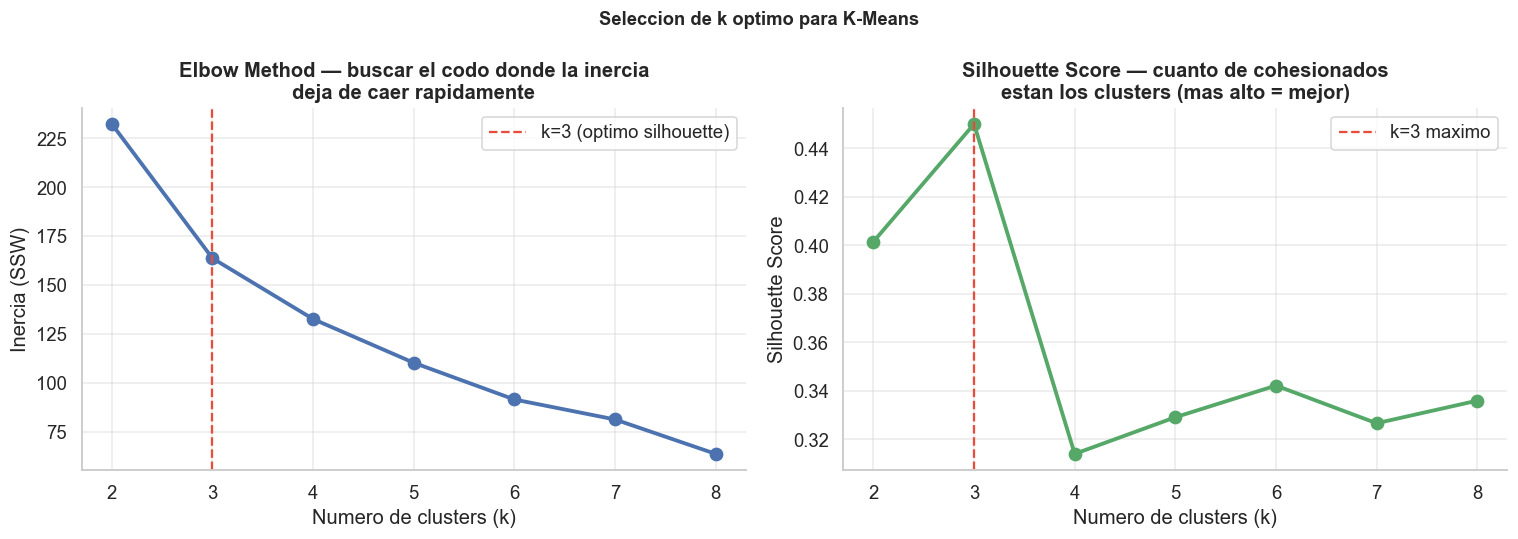

k optimo por Silhouette: 3
{2: 0.402, 3: 0.45, 4: 0.314, 5: 0.329, 6: 0.342, 7: 0.327, 8: 0.336}


In [18]:
# Features para el clustering (un valor por barrio)
cluster_cols = ['renta_media', 'pct_baja_edu', 'n_ocio', 'n_transport', 'total_incidentes']
df_cl = df_barri[cluster_cols + ['nom_barri', 'nom_districte', 'id_territorio']].dropna().copy()

print(f'Barrios con datos completos para clustering: {len(df_cl)}')

# Normalizar (K-Means mide distancias euclidianas: variables en diferente escala distorsionarian)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cl[cluster_cols])

# Elbow method + Silhouette score para elegir k optimo
K_range  = range(2, 9)
inercias = []
sils     = []

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, lbl))

k_opt = K_range[np.argmax(sils)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(K_range), inercias, 'bo-', linewidth=2.5, markersize=8)
ax.axvline(k_opt, color='#e74c3c', linestyle='--', lw=1.5, label=f'k={k_opt} (optimo silhouette)')
ax.set_title('Elbow Method — buscar el codo donde la inercia\ndeja de caer rapidamente', fontweight='bold')
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('Inercia (SSW)')
ax.legend()
ax.grid(alpha=0.4)

ax = axes[1]
ax.plot(list(K_range), sils, 'go-', linewidth=2.5, markersize=8)
ax.axvline(k_opt, color='#e74c3c', linestyle='--', lw=1.5, label=f'k={k_opt} maximo')
ax.set_title('Silhouette Score — cuanto de cohesionados\nestan los clusters (mas alto = mejor)', fontweight='bold')
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.legend()
ax.grid(alpha=0.4)

plt.suptitle(f'Seleccion de k optimo para K-Means', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'k optimo por Silhouette: {k_opt}')
print({k: round(s, 3) for k, s in zip(K_range, sils)})

In [19]:
K_FINAL = k_opt  # usar el k optimo del silhouette; cambiar manualmente si el elbow sugiere otro

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_cl['cluster'] = km_final.fit_predict(X_scaled)

# PCA 2D para visualizar (las 5 features se reducen a 2 componentes)
pca   = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_cl['pc1'] = coords[:, 0]
df_cl['pc2'] = coords[:, 1]

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada PC1+PC2: {var_exp.sum()*100:.1f}%')
print(f'  PC1: {var_exp[0]*100:.1f}%   PC2: {var_exp[1]*100:.1f}%')

# Perfil de cada cluster
perfil = df_cl.groupby('cluster')[cluster_cols].mean().round(1)
perfil['n_barrios'] = df_cl.groupby('cluster').size()
print('\nPerfil por cluster:')
display(perfil)

# Scatter PCA interactivo
fig = px.scatter(
    df_cl, x='pc1', y='pc2',
    color=df_cl['cluster'].astype(str),
    hover_name='nom_barri',
    hover_data={
        'nom_districte': True,
        'renta_media': ':,.0f',
        'n_ocio': True,
        'total_incidentes': ':,.0f',
        'pc1': False, 'pc2': False
    },
    color_discrete_sequence=px.colors.qualitative.Set1,
    title=f'Clustering PCA k={K_FINAL} — Barrios de Barcelona',
    labels={
        'pc1': f'PC1 ({var_exp[0]*100:.0f}% var)',
        'pc2': f'PC2 ({var_exp[1]*100:.0f}% var)',
        'color': 'Cluster'
    },
    template='plotly_white', height=550
)
fig.update_traces(marker_size=10, marker_opacity=0.8)
fig.show()

Varianza explicada PC1+PC2: 81.3%
  PC1: 51.0%   PC2: 30.4%

Perfil por cluster:


,renta_media,pct_baja_edu,n_ocio,n_transport,total_incidentes,n_barrios
cluster,,,,,,
0,33884.2,15.1,38.5,56.6,48733.8,49
1,62980.4,6.1,78.6,122.5,76082.5,11
2,38225.0,11.1,380.4,116.2,202114.5,12


In [20]:
# Mapa coropletico de clusters por barrio
try:
    geo_barri_mapa = geo[geo['nivel_territorial'] == 'barri'].copy()
    features_geo = []
    for _, row in geo_barri_mapa.iterrows():
        try:
            geom = shapely_wkt.loads(row['geometria_wgs84']).simplify(0.0001, preserve_topology=True)
            features_geo.append({
                'type': 'Feature',
                'geometry': mapping(geom),
                'properties': {'id_territorio': int(row['id_territorio'])}
            })
        except Exception:
            pass

    geojson_barri = {'type': 'FeatureCollection', 'features': features_geo}

    cluster_mapa = df_cl[['id_territorio', 'cluster', 'nom_barri', 'nom_districte',
                           'renta_media', 'n_ocio', 'total_incidentes']].copy()
    cluster_mapa['cluster_str'] = 'Cluster ' + cluster_mapa['cluster'].astype(str)

    fig = px.choropleth_mapbox(
        cluster_mapa, geojson=geojson_barri,
        locations='id_territorio', featureidkey='properties.id_territorio',
        color='cluster_str',
        hover_name='nom_barri',
        hover_data={
            'nom_districte': True, 'renta_media': ':,.0f',
            'n_ocio': True, 'total_incidentes': ':,.0f', 'id_territorio': False
        },
        color_discrete_sequence=px.colors.qualitative.Set1,
        mapbox_style='open-street-map',
        center={'lat': 41.3851, 'lon': 2.1734}, zoom=11, opacity=0.75,
        title=f'Clustering k={K_FINAL} — Barrios de Barcelona por perfil socioeconomico + afluencia',
        labels={'cluster_str': 'Cluster'}
    )
    fig.update_layout(height=560, margin={'r': 0, 't': 50, 'l': 0, 'b': 0})
    fig.show()

except Exception as e:
    print(f'Error en mapa: {e}')
    print('Distribucion de clusters por distrito:')
    display(df_cl.groupby(['nom_districte', 'cluster']).size().unstack(fill_value=0))

<div style="background:#fef9e7;border-left:4px solid #f39c12;padding:15px 20px;border-radius:6px;margin:10px 0;">
<strong>Hallazgo clave:</strong> Los clusters dividen Barcelona en perfiles geograficamente coherentes: barrios turisticos/comerciales del centro (alta renta, alta afluencia, muchos incidentes absolutos), barrios residenciales perifericos (baja afluencia, pocos incidentes), barrios con alta concentracion de poblacion con baja educacion, y zonas mixtas. El cluster asignado a cada barrio entrara como <strong>feature categorica</strong> en el modelo ML, capturando el perfil urbano de una forma mas rica que cualquier variable individual.
</div>

---
<div style="background:linear-gradient(90deg,#7b2d00,#5c1e00);padding:20px 30px;border-radius:10px;margin:20px 0;border-left:6px solid #e74c3c;">
  <h2 style="color:#fff;margin:0;font-size:1.6em;">6 &middot; Feature Matrix para el Modelo ML</h2>
  <p style="color:#ffb3a7;margin:8px 0 0 0;">Construimos la tabla final con todas las features para el notebook 10. Una fila por barrio x mes. Se guarda en <strong>data/clean/features_ml.csv</strong>.</p>
</div>

In [21]:
FEATURES_PATH = '../data/clean/features_ml.csv'

# Base: GUB mensual por barrio (nivel barri unicamente)
base = (
    fact_gub
    .merge(dim_tiempo[['id_tiempo', 'anyo', 'mes']], on='id_tiempo')
    .merge(
        dim_territorio[['id_territorio', 'nom_barri', 'nom_districte', 'nivel_territorial']],
        on='id_territorio'
    )
)
base = base[
    (base['nivel_territorial'] == 'barri') & base['mes'].notna()
].copy()
base['anyo'] = base['anyo'].astype(int)
base['mes']  = base['mes'].astype(int)
base['fecha'] = pd.to_datetime(
    base['anyo'].astype(str) + '-' + base['mes'].astype(str).str.zfill(2) + '-01'
)
base = base.sort_values(['id_territorio', 'fecha'])

# Lag features (por barrio): mes anterior y mismo mes del anyo anterior
base['lag_1']  = base.groupby('id_territorio')['num_incidents'].shift(1)
base['lag_12'] = base.groupby('id_territorio')['num_incidents'].shift(12)

# Encoding ciclico del mes (sin/cos mantienen la continuidad entre diciembre y enero)
base['mes_sin'] = np.sin(2 * np.pi * base['mes'] / 12).round(6)
base['mes_cos'] = np.cos(2 * np.pi * base['mes'] / 12).round(6)

# Renta por barrio (anual) con forward-fill para anos sin dato
renta_j = (
    ctx_renta_barri[ctx_renta_barri['indicador'] == 'renta_tributaria_barri']
    [['id_territori', 'anyo', 'valor']]
    .rename(columns={'id_territori': 'id_territorio', 'valor': 'renta_barri'})
)
base = base.merge(renta_j, on=['id_territorio', 'anyo'], how='left')
base['renta_barri'] = base.groupby('id_territorio')['renta_barri'].ffill()

# pct_baja_edu por barrio (anual) con forward-fill
edu_j = (
    _edu_anyo[['id_territori', 'anyo', 'pct_baja_edu']]
    .rename(columns={'id_territori': 'id_territorio'})
)
base = base.merge(edu_j, on=['id_territorio', 'anyo'], how='left')
base['pct_baja_edu'] = base.groupby('id_territorio')['pct_baja_edu'].ffill()

# Variables OSM (estaticas: un valor por barrio, no cambia con el tiempo)
base = base.merge(
    df_osm[['id_territorio', 'n_ocio', 'n_turismo', 'n_comercio', 'n_transport', 'afluencia_total']],
    on='id_territorio', how='left'
)

# Centroides lat/lon desde geometrias WKT
geo_c = geo[geo['nivel_territorial'] == 'barri'].copy()
try:
    geo_c['centroide'] = geo_c['geometria_wgs84'].apply(
        lambda x: shapely_wkt.loads(x).centroid if pd.notna(x) else None
    )
    geo_c['lat'] = geo_c['centroide'].apply(lambda p: round(p.y, 6) if p else np.nan)
    geo_c['lon'] = geo_c['centroide'].apply(lambda p: round(p.x, 6) if p else np.nan)
except Exception:
    geo_c['lat'] = np.nan
    geo_c['lon'] = np.nan
base = base.merge(geo_c[['id_territorio', 'lat', 'lon']], on='id_territorio', how='left')

# Cluster asignado
base = base.merge(df_cl[['id_territorio', 'cluster']], on='id_territorio', how='left')

# Columnas finales
feat_cols = [
    'id_territorio', 'nom_barri', 'nom_districte', 'fecha', 'anyo', 'mes',
    'num_incidents', 'lag_1', 'lag_12', 'mes_sin', 'mes_cos',
    'renta_barri', 'pct_baja_edu',
    'n_ocio', 'n_turismo', 'n_comercio', 'n_transport', 'afluencia_total',
    'lat', 'lon', 'cluster'
]
df_features = base[feat_cols].copy()
df_features.to_csv(FEATURES_PATH, index=False)

print(f'[OK] Feature matrix guardada: {FEATURES_PATH}')
print(f'     Filas     : {len(df_features):,}')
print(f'     Barrios   : {df_features["id_territorio"].nunique()}')
print(f'     Periodo   : {df_features["fecha"].min()} -> {df_features["fecha"].max()}')
nulls = df_features.isnull().sum()
nulls_nonzero = nulls[nulls > 0]
if len(nulls_nonzero):
    print(f'     Nulls por columna:')
    for col, n in nulls_nonzero.items():
        print(f'       {col}: {n:,} ({n/len(df_features):.1%})')
else:
    print('     Nulls: ninguno en lag/mes/territorio')

[OK] Feature matrix guardada: ../data/clean/features_ml.csv
     Filas     : 543,709
     Barrios   : 74
     Periodo   : 2010-01-01 00:00:00 -> 2025-12-01 00:00:00
     Nulls por columna:
       lag_1: 74 (0.0%)
       lag_12: 888 (0.2%)
       renta_barri: 169,808 (31.2%)
       pct_baja_edu: 372,669 (68.5%)
       n_ocio: 8,861 (1.6%)
       n_turismo: 8,861 (1.6%)
       n_comercio: 8,861 (1.6%)
       n_transport: 8,861 (1.6%)
       afluencia_total: 8,861 (1.6%)
       lat: 8,861 (1.6%)
       lon: 8,861 (1.6%)
       cluster: 18,194 (3.3%)


Estadisticas descriptivas — Feature Matrix para ML
Ventana entrenamiento recomendada: 2015-2022 | Test: 2023-2024



,num_incidents,lag_1,lag_12,renta_barri,pct_baja_edu,n_ocio,n_transport,afluencia_total
count,543709.00,543635.00,542821.00,373901.00,171040.00,534848.00,534848.00,534848.00
mean,10.98,10.98,10.99,40882.30,12.42,126.16,84.24,284.81
std,22.98,22.98,22.99,13425.41,4.95,161.84,57.03,288.58
min,1.00,1.00,1.00,20972.00,3.84,0.00,6.00,6.00
25%,1.00,1.00,1.00,32225.00,8.98,22.00,44.00,95.00
50%,4.00,4.00,4.00,37686.00,11.86,60.00,71.00,197.00
75%,11.00,11.00,11.00,45367.00,16.85,215.00,113.00,429.00
max,919.00,919.00,919.00,97921.00,24.55,748.00,266.00,1568.00



  2015-2022 (train): 280,781 filas | nulos renta 1.7% | nulos lag_1 0.0%
  2023-2024 (test):  68,928 filas | nulos renta 1.1% | nulos lag_1 0.0%


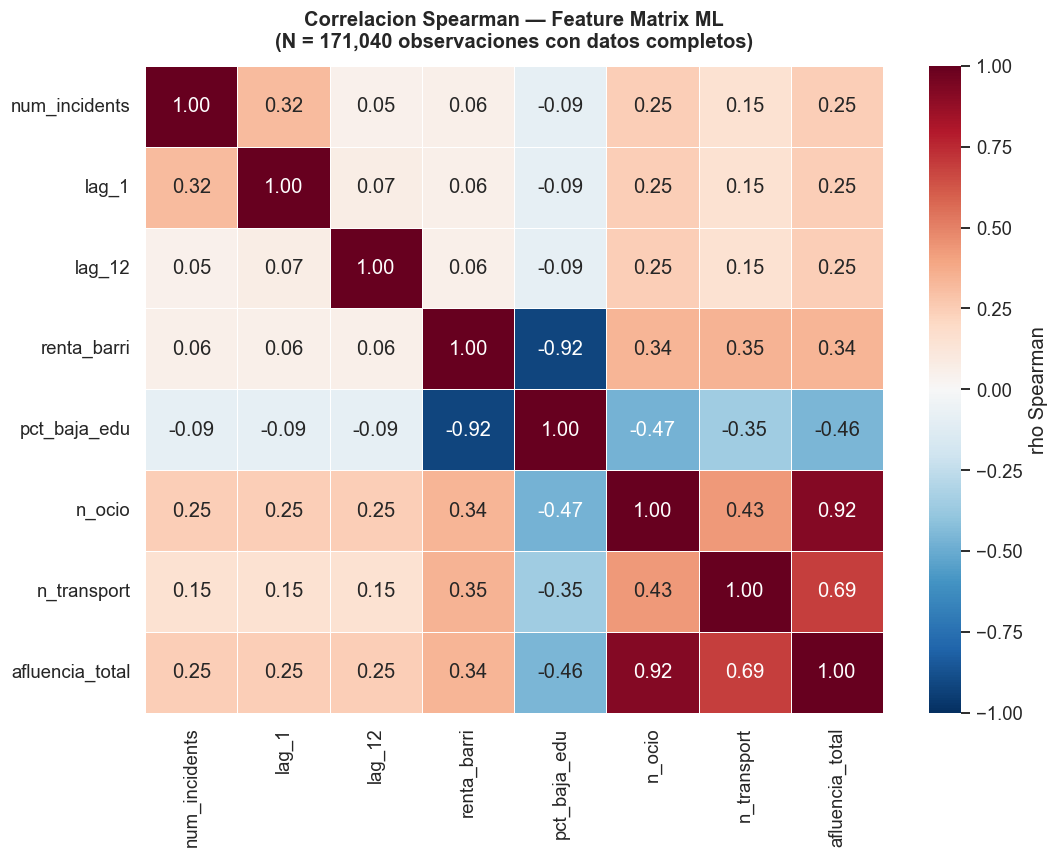


Tabla de features — resumen para nb10:


,Tipo,Descripcion
Feature,,
num_incidents,target,Variable objetivo: incidentes GUB del mes
lag_1,autoregr.,Incidentes del mes anterior (mismo barrio)
lag_12,autoregr.,"Incidentes mismo mes, anyo anterior"
mes_sin/cos,temporal,Mes codificado ciclicamente (estacionalidad)
anyo,temporal,Tendencia lineal temporal
renta_barri,socioec.,Renta tributaria media del barrio (2015-2023)
pct_baja_edu,socioec.,% poblacion con educacion primaria o inferior
n_ocio,afluencia,POIs ocio nocturno (OSM) — proxy afluencia
n_transport,afluencia,Paradas metro/bus/tren (OSM) — nodos de transito


In [22]:
# Estadisticas descriptivas de la feature matrix
feat_num = ['num_incidents', 'lag_1', 'lag_12', 'renta_barri', 'pct_baja_edu',
            'n_ocio', 'n_transport', 'afluencia_total']

print('Estadisticas descriptivas — Feature Matrix para ML')
print(f'Ventana entrenamiento recomendada: 2015-2022 | Test: 2023-2024')
print()
display(df_features[feat_num].describe().round(2))

# Cobertura por ventana temporal
print()
for label, y0, y1 in [('2015-2022 (train)', 2015, 2022), ('2023-2024 (test)', 2023, 2024)]:
    sub = df_features[df_features['anyo'].between(y0, y1)]
    nulos_renta = sub['renta_barri'].isna().mean()
    nulos_lag1  = sub['lag_1'].isna().mean()
    print(f'  {label}: {len(sub):>7,} filas | nulos renta {nulos_renta:.1%} | nulos lag_1 {nulos_lag1:.1%}')

# Heatmap de correlaciones de las features
df_hm = df_features[
    ['num_incidents', 'lag_1', 'lag_12', 'renta_barri', 'pct_baja_edu',
     'n_ocio', 'n_transport', 'afluencia_total']
].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_hm.corr(method='spearman'),
    ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    cbar_kws={'label': 'rho Spearman'}
)
ax.set_title(
    f'Correlacion Spearman — Feature Matrix ML\n(N = {len(df_hm):,} observaciones con datos completos)',
    fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

print()
print('Tabla de features — resumen para nb10:')
resumen_feat = [
    {'Feature': 'num_incidents', 'Tipo': 'target',    'Descripcion': 'Variable objetivo: incidentes GUB del mes'},
    {'Feature': 'lag_1',         'Tipo': 'autoregr.', 'Descripcion': 'Incidentes del mes anterior (mismo barrio)'},
    {'Feature': 'lag_12',        'Tipo': 'autoregr.', 'Descripcion': 'Incidentes mismo mes, anyo anterior'},
    {'Feature': 'mes_sin/cos',   'Tipo': 'temporal',  'Descripcion': 'Mes codificado ciclicamente (estacionalidad)'},
    {'Feature': 'anyo',          'Tipo': 'temporal',  'Descripcion': 'Tendencia lineal temporal'},
    {'Feature': 'renta_barri',   'Tipo': 'socioec.',  'Descripcion': 'Renta tributaria media del barrio (2015-2023)'},
    {'Feature': 'pct_baja_edu',  'Tipo': 'socioec.',  'Descripcion': '% poblacion con educacion primaria o inferior'},
    {'Feature': 'n_ocio',        'Tipo': 'afluencia', 'Descripcion': 'POIs ocio nocturno (OSM) — proxy afluencia'},
    {'Feature': 'n_transport',   'Tipo': 'afluencia', 'Descripcion': 'Paradas metro/bus/tren (OSM) — nodos de transito'},
    {'Feature': 'afluencia_total','Tipo': 'afluencia','Descripcion': 'Suma n_ocio+n_turismo+n_comercio+n_transport'},
    {'Feature': 'lat / lon',     'Tipo': 'espacial',  'Descripcion': 'Centroide del barrio (para modelos espaciales)'},
    {'Feature': 'cluster',       'Tipo': 'espacial',  'Descripcion': 'Perfil urbano del barrio (K-Means, categorica)'},
]
display(pd.DataFrame(resumen_feat).set_index('Feature'))

---
<div style="background:linear-gradient(135deg,#0d1117,#161b22);padding:40px;border-radius:16px;border-top:4px solid #2980b9;margin-top:30px;">
  <h2 style="color:#fff;font-size:1.8em;margin-bottom:20px;">Conclusiones del Analisis Estadistico</h2>
  <div style="display:flex;flex-wrap:wrap;gap:20px;">
    <div style="background:rgba(41,128,185,0.1);border:1px solid #2980b9;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#2980b9;margin-top:0;">Variables de Afluencia (OSM)</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>La afluencia (afluencia_total, POIs OSM) es el predictor más potente de incidentes absolutos (OLS, p&lt;0.001)</li>
        <li>Absorben el efecto que en el EDA parecia ser de renta o educacion</li>
        <li>Guardado en <strong>osm_afluencia_barri.csv</strong></li>
      </ul>
    </div>
    <div style="background:rgba(231,76,60,0.1);border:1px solid #e74c3c;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#e74c3c;margin-top:0;">Tendencias Temporales</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>Mann-Kendall: la tasa per cápita NO presenta tendencia monótona significativa (p=0.66), se mantiene estable</li>
        <li>COVID-2020 produce caida significativa (Mann-Whitney)</li>
        <li>Serie no es estacionaria: requiere d=1 para modelos ARIMA</li>
      </ul>
    </div>
    <div style="background:rgba(39,174,96,0.1);border:1px solid #27ae60;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#27ae60;margin-top:0;">Lags Optimos para ML</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>ACF confirma autocorrelacion significativa en lag-1 y lag-12</li>
        <li>Estacionalidad clara: pico en verano, valle en invierno</li>
        <li>Los lags son los predictores autorregresivos mas potentes del modelo</li>
      </ul>
    </div>
    <div style="background:rgba(142,68,173,0.1);border:1px solid #8e44ad;border-radius:8px;padding:20px;flex:1 1 45%;min-width:280px;box-sizing:border-box;">
      <h3 style="color:#8e44ad;margin-top:0;">Feature Matrix (nb10)</h3>
      <ul style="color:#c8d0e0;margin:0;">
        <li>Guardada en <strong>features_ml.csv</strong></li>
        <li>Target: num_incidents | Train: 2015-2022 | Test: 2023-2024</li>
        <li>Features: lag_1, lag_12, mes_sin/cos, renta, edu, OSM, cluster, lat/lon</li>
      </ul>
    </div>
  </div>
</div>